In [11]:
import xarray as xr
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.floating_axes as FA
import mpl_toolkits.axisartist.grid_finder as GF

In [12]:
# mask
def coastal_band_mask(ds, var='u10', iterations=10):
    """
    Create a coastal band mask by dilating the coastline edge.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain 2D lat/lon coords and the target variable.
    var : str
        Variable name used to detect land (NaN) vs ocean.
    iterations : int
        Number of dilation steps (~10 km per iteration on a ~10 km grid).

    Returns
    -------
    da_mask : xr.DataArray
        Boolean mask (True inside the coastal band).
    """
    valid2d = np.isfinite(ds[var].mean(dim='time')).values.astype(bool)

    eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
    coast = valid2d & (~eroded)

    band = binary_dilation(coast, structure=np.ones((3, 3)), iterations=iterations) & valid2d

    da_mask = xr.DataArray(
        band,
        dims=('lat', 'lon'),
        coords={'lat': ds['lat'], 'lon': ds['lon']},
    )
    return da_mask

In [13]:
winds_ds = xr.open_dataset('winds_NHUS.nc').compute()
winds_ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    u10      (time, lat, lon) float64 1GB 1.432 1.435 1.439 ... nan nan nan
    v10      (time, lat, lon) float64 1GB -0.9696 -0.999 -1.031 ... nan nan nan

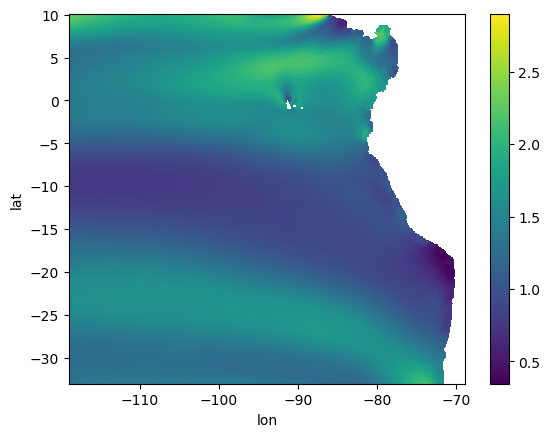

In [4]:
((winds_ds.u10**2 + winds_ds.v10**2)**0.5).std('time').plot()

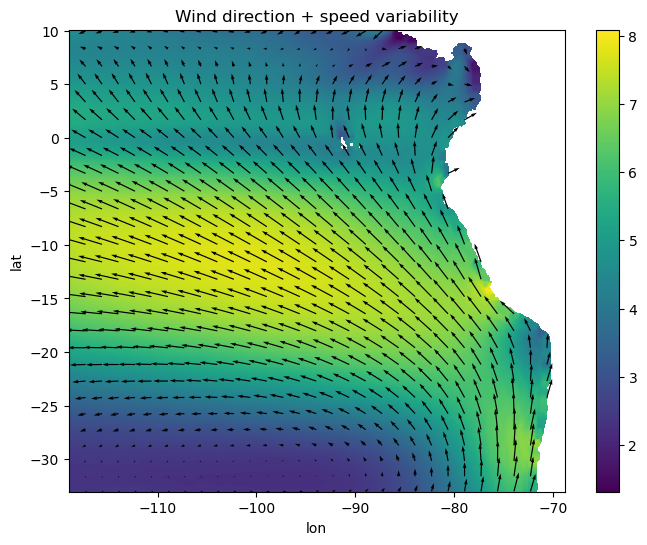

In [16]:
import matplotlib.pyplot as plt

# Mean wind (or you can use std, but direction usually from mean)
u = winds_ds.u10.mean('time')
v = winds_ds.v10.mean('time')

# Subsample (VERY important)
step = 20
u_ = u[::step, ::step]
v_ = v[::step, ::step]
lon_ = winds_ds.lon[::step]
lat_ = winds_ds.lat[::step]

# Plot background (your original idea)
fig, ax = plt.subplots(figsize=(8,6))
((winds_ds.u10**2 + winds_ds.v10**2)**0.5).mean('time').plot(ax=ax)

# Quiver (direction)
ax.quiver(lon_, lat_, u_, v_, scale=150)

plt.title("Wind direction + speed variability")
plt.show()